# Diabetes Hospital Readmissions EDA

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('diabetic_data.csv', na_values=['?'], low_memory=False)
df.shape

(101766, 50)

In [2]:
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)
df['readmit_any'] = df['readmitted'].isin(['<30', '>30']).astype(int)
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']
df['age'] = pd.Categorical(df['age'], categories=age_order, ordered=True)
df['age_mid'] = df['age'].astype(str).str.extract(r'\[(\d+)-(\d+)\)').astype(float).mean(axis=1)
df['total_prior_visits'] = df['number_inpatient'] + df['number_emergency'] + df['number_outpatient']
df['a1c_group'] = df['A1Cresult'].fillna('Not measured')
df['changed_med'] = df['change'].map({'Ch': 'Medication changed', 'No': 'No medication change'})
df['discharge_group'] = df['discharge_disposition_id'].map({
    1: 'Home', 2: 'Transfer', 3: 'SNF/ICF', 4: 'SNF/ICF', 5: 'Transfer',
    6: 'Home health', 7: 'Left AMA', 11: 'Expired', 13: 'Hospice', 14: 'Hospice',
    18: 'Unknown', 22: 'Rehab/LTCH', 23: 'Rehab/LTCH', 25: 'Unknown', 26: 'Unknown'
}).fillna('Other')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,change,diabetesMed,readmitted,readmit_30,readmit_any,age_mid,total_prior_visits,a1c_group,changed_med,discharge_group
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,NO,0,0,5.0,0,Not measured,No medication change,Unknown
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,Ch,Yes,>30,0,1,15.0,0,Not measured,Medication changed,Home
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,Yes,NO,0,0,25.0,3,Not measured,No medication change,Home
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,Ch,Yes,NO,0,0,35.0,0,Not measured,Medication changed,Home
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,Ch,Yes,NO,0,0,45.0,0,Not measured,Medication changed,Home


In [3]:
numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
categorical_cols = ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'payer_code', 'medical_specialty', 'readmitted']

numeric_summary = pd.DataFrame([
    {'variable': col, 'missing_rate': df[col].isna().mean(), 'min': df[col].min(), 'max': df[col].max(), 'mean': df[col].mean(), 'median': df[col].median(), 'std': df[col].std()}
    for col in numeric_cols
])

def top3(series):
    return '; '.join(f'{idx}: {val}' for idx, val in series.astype('object').value_counts(dropna=True).head(3).items())

categorical_summary = pd.DataFrame([
    {'variable': col, 'missing_rate': df[col].isna().mean(), 'n_distinct': df[col].nunique(dropna=True), 'top_3': top3(df[col])}
    for col in categorical_cols
])

numeric_summary, categorical_summary

(             variable  missing_rate  min  max       mean  median        std
 0    time_in_hospital           0.0    1   14   4.395987     4.0   2.985108
 1  num_lab_procedures           0.0    1  132  43.095641    44.0  19.674362
 2      num_procedures           0.0    0    6   1.339730     1.0   1.705807
 3     num_medications           0.0    1   81  16.021844    15.0   8.127566
 4   number_outpatient           0.0    0   42   0.369357     0.0   1.267265
 5    number_emergency           0.0    0   76   0.197836     0.0   0.930472
 6    number_inpatient           0.0    0   21   0.635566     0.0   1.262863
 7    number_diagnoses           0.0    1   16   7.422607     8.0   1.933600,
                    variable  missing_rate  n_distinct  \
 0                      race      0.022336           5   
 1                    gender      0.000000           3   
 2                       age      0.000000          10   
 3         admission_type_id      0.000000           8   
 4  discharge_di

In [4]:
plt.rcParams.update({'figure.dpi': 160, 'savefig.dpi': 220, 'font.size': 10, 'axes.titlesize': 12, 'axes.labelsize': 10, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid', palette='colorblind')

def savefig(name):
    path = f'{name}.png'
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    plt.close()
    return path

saved_figures = {}

## Variation within variables

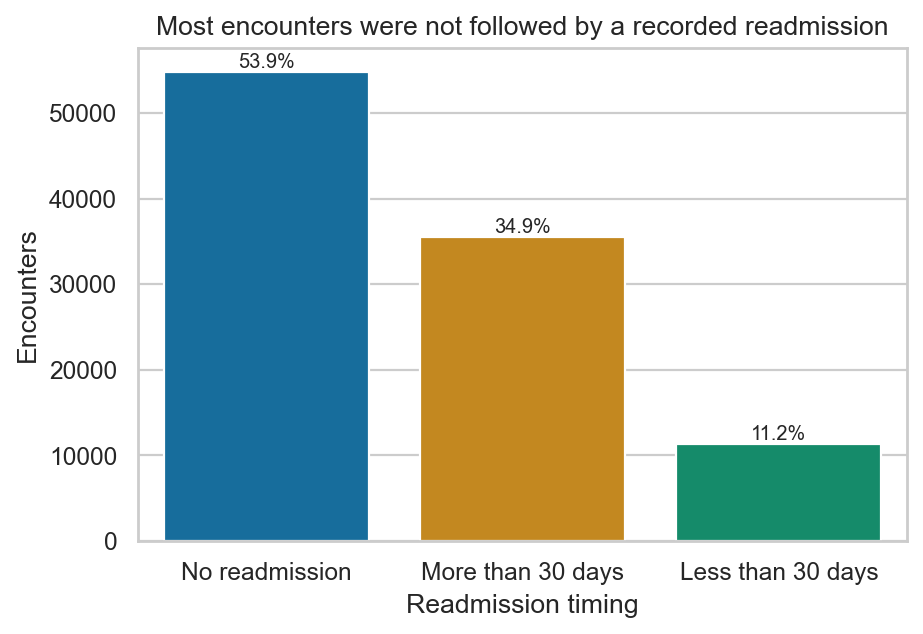

In [5]:
rate = df.groupby('readmitted', observed=True).size().reindex(['NO', '>30', '<30'])

plt.figure(figsize=(6.2, 4.0))
ax = sns.barplot(
    x=['No readmission', 'More than 30 days', 'Less than 30 days'],
    y=rate.values,
    hue=['No readmission', 'More than 30 days', 'Less than 30 days'],
    legend=False
)

ax.set(
    title='Most encounters were not followed by a recorded readmission',
    xlabel='Readmission timing',
    ylabel='Encounters'
)

for i, v in enumerate(rate.values):
    ax.text(i, v, f'{v/len(df):.1%}', ha='center', va='bottom', fontsize=9)

saved_figures['readmitted_distribution'] = savefig('readmitted_distribution')

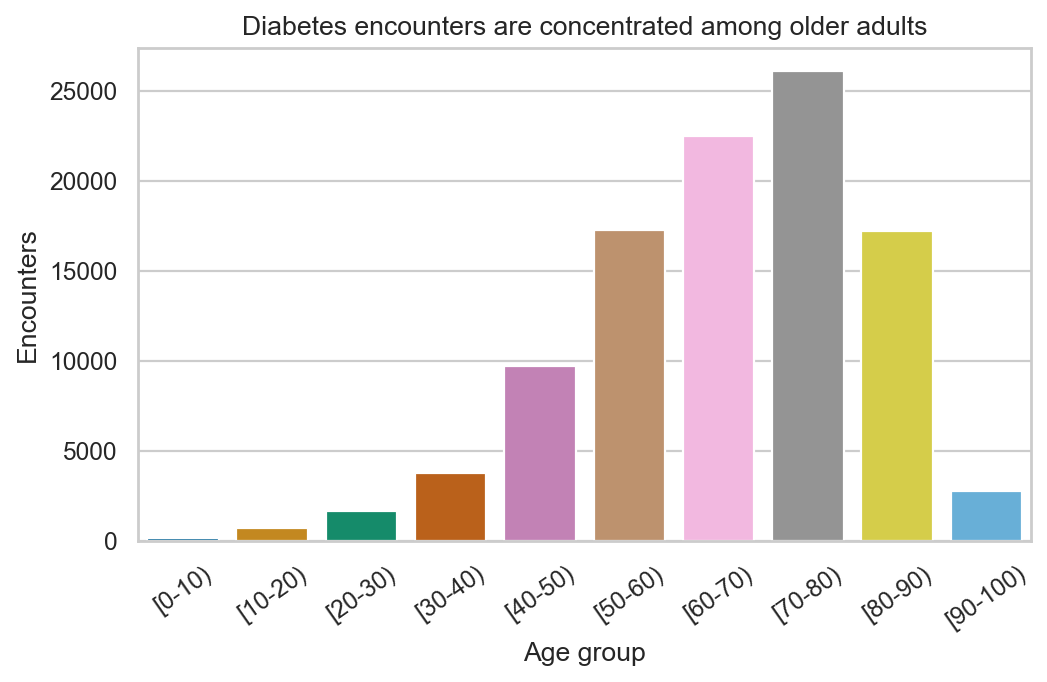

In [6]:
age_counts = df['age'].value_counts().sort_index()
plt.figure(figsize=(7.2, 4.0))
ax = sns.barplot(x=age_counts.index.astype(str), y=age_counts.values, hue=age_counts.index.astype(str), legend=False)
ax.set(title='Diabetes encounters are concentrated among older adults', xlabel='Age group', ylabel='Encounters')
ax.tick_params(axis='x', rotation=35)
saved_figures['age_distribution'] = savefig('age_distribution')

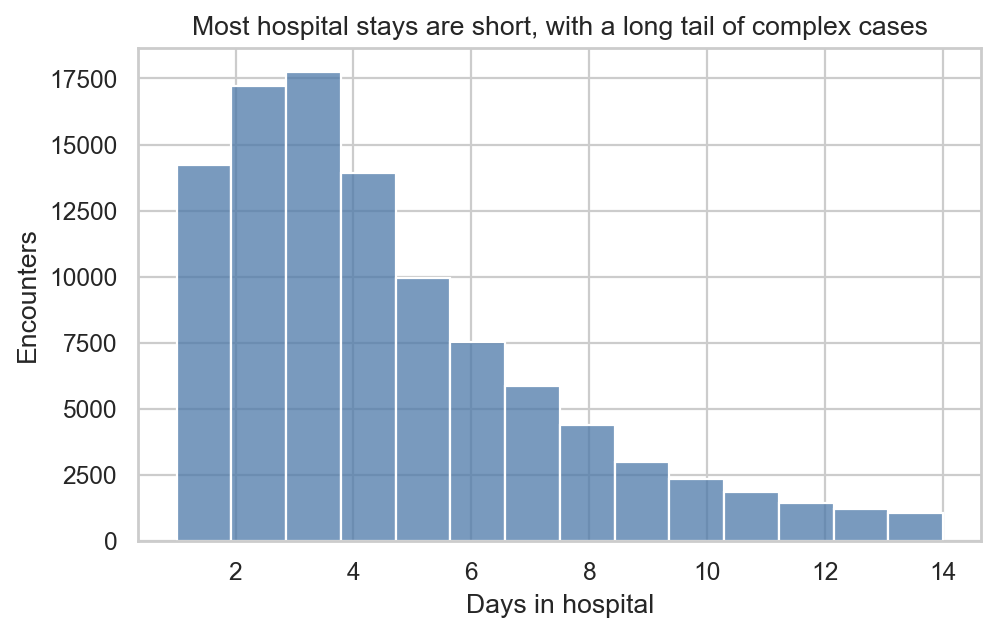

In [7]:
plt.figure(figsize=(6.8, 4.0))
ax = sns.histplot(data=df, x='time_in_hospital', bins=14, color='#4c78a8')
ax.set(title='Most hospital stays are short, with a long tail of complex cases', xlabel='Days in hospital', ylabel='Encounters')
saved_figures['time_in_hospital'] = savefig('time_in_hospital')

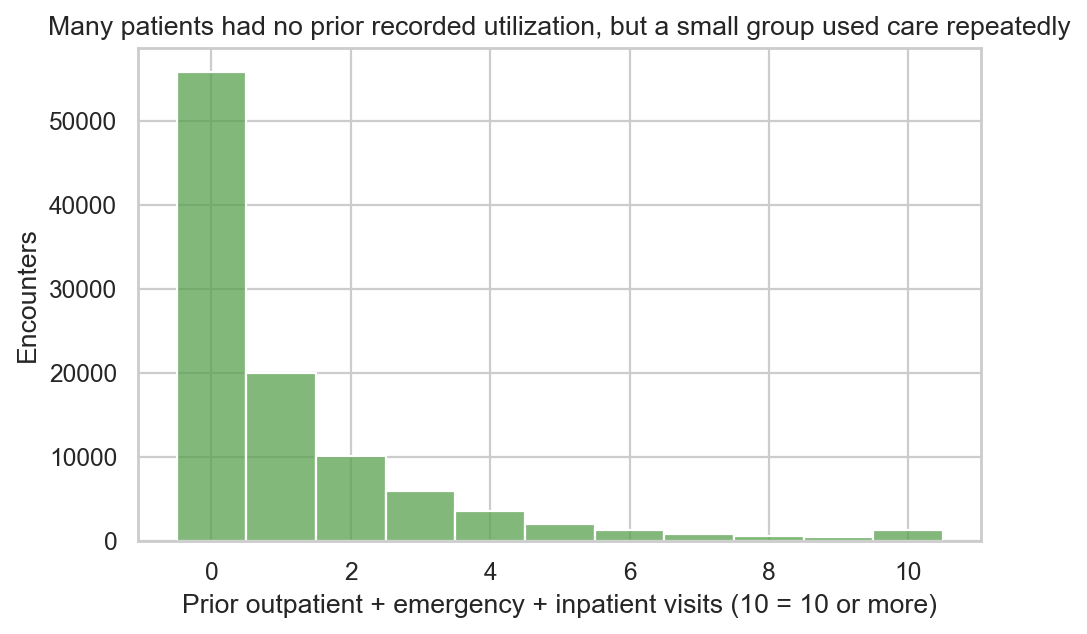

In [8]:
prior = df['total_prior_visits'].clip(upper=10)
plt.figure(figsize=(6.8, 4.0))
ax = sns.histplot(prior, discrete=True, color='#59a14f')
ax.set(title='Many patients had no prior recorded utilization, but a small group used care repeatedly', xlabel='Prior outpatient + emergency + inpatient visits (10 = 10 or more)', ylabel='Encounters')
saved_figures['prior_visits'] = savefig('prior_visits')

## Covariation motivated by research questions

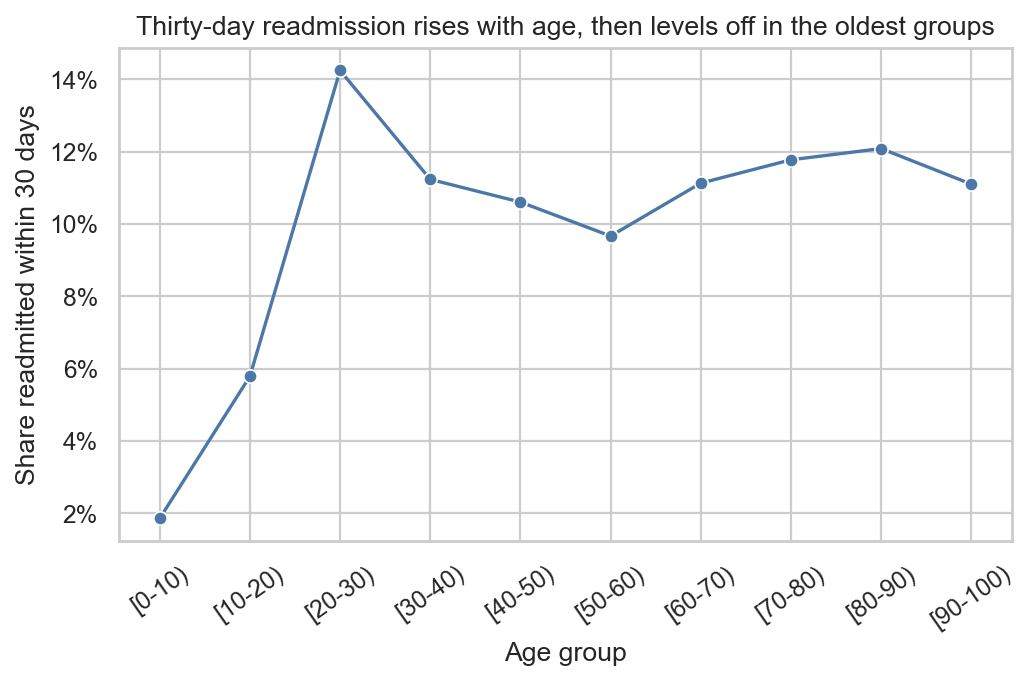

In [9]:
age_rate = df.groupby('age', observed=True)['readmit_30'].mean().reset_index()
plt.figure(figsize=(7.2, 4.0))
ax = sns.lineplot(data=age_rate, x='age', y='readmit_30', marker='o', color='#4c78a8')
ax.set(title='Thirty-day readmission rises with age, then levels off in the oldest groups', xlabel='Age group', ylabel='Share readmitted within 30 days')
ax.tick_params(axis='x', rotation=35)
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
saved_figures['rq_age_readmit'] = savefig('rq_age_readmit')

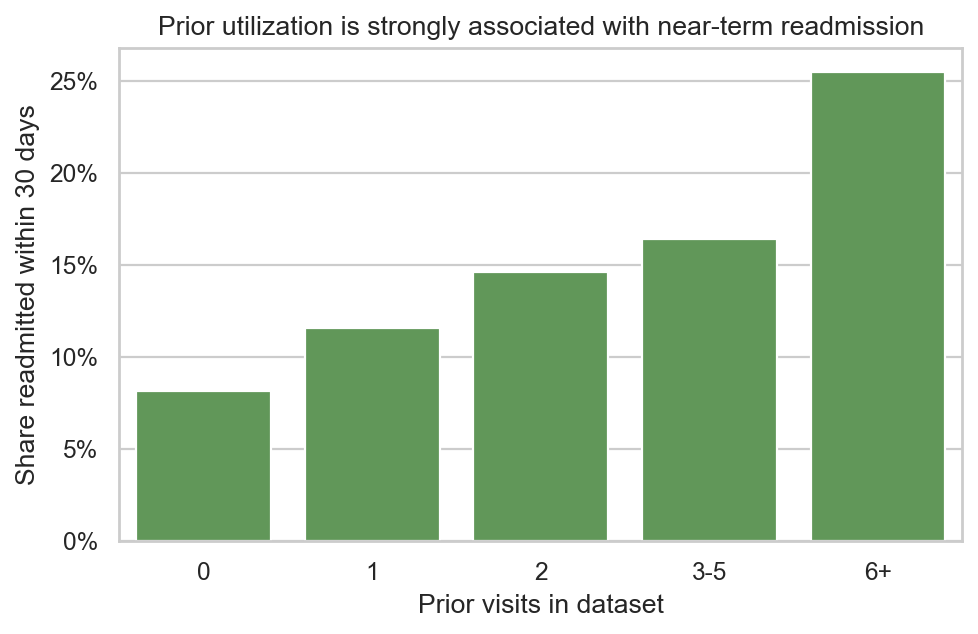

In [10]:
util = df.groupby(pd.cut(df['total_prior_visits'], [-1, 0, 1, 2, 5, 100], labels=['0', '1', '2', '3-5', '6+']), observed=True)['readmit_30'].mean().reset_index()
plt.figure(figsize=(6.8, 4.0))
ax = sns.barplot(data=util, x='total_prior_visits', y='readmit_30', color='#59a14f')
ax.set(title='Prior utilization is strongly associated with near-term readmission', xlabel='Prior visits in dataset', ylabel='Share readmitted within 30 days')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
saved_figures['rq_prior_utilization'] = savefig('rq_prior_utilization')

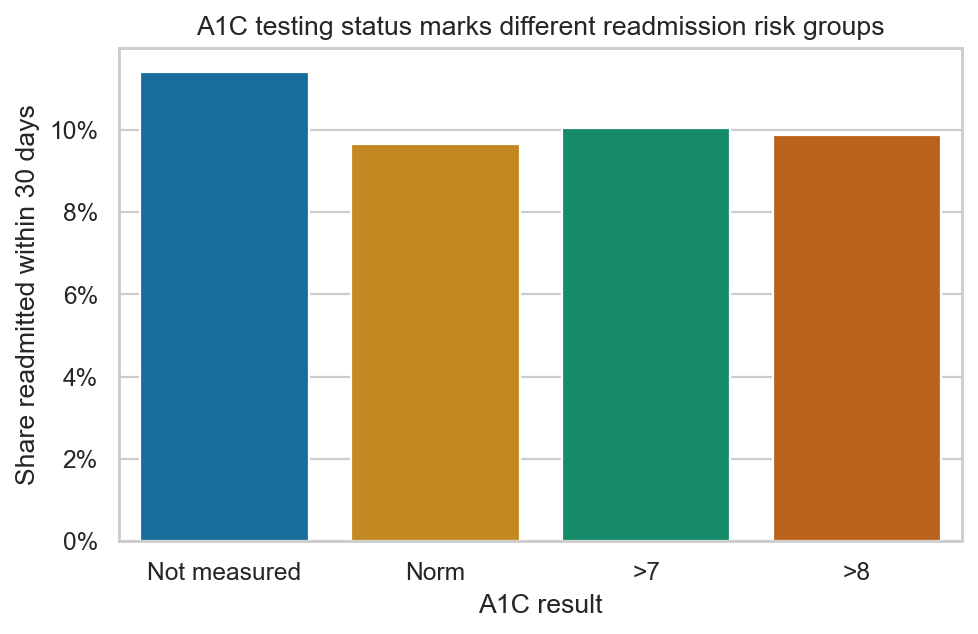

In [11]:
a1c = df.groupby('a1c_group', observed=True)['readmit_30'].agg(['mean', 'size']).reindex(['Not measured', 'Norm', '>7', '>8']).reset_index()
plt.figure(figsize=(6.8, 4.0))
ax = sns.barplot(data=a1c, x='a1c_group', y='mean', hue='a1c_group', legend=False)
ax.set(title='A1C testing status marks different readmission risk groups', xlabel='A1C result', ylabel='Share readmitted within 30 days')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
saved_figures['rq_a1c_readmit'] = savefig('rq_a1c_readmit')

## Surprising findings and subgroup heterogeneity

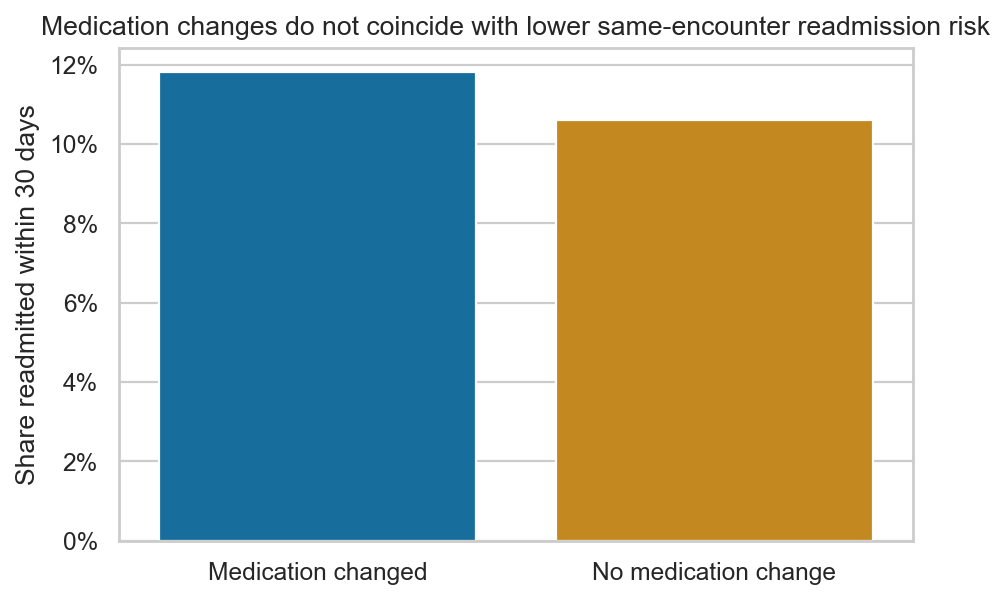

In [12]:
med = df.groupby('changed_med', observed=True)['readmit_30'].agg(['mean', 'size']).reset_index()
plt.figure(figsize=(6.4, 4.0))
ax = sns.barplot(data=med, x='changed_med', y='mean', hue='changed_med', legend=False)
ax.set(title='Medication changes do not coincide with lower same-encounter readmission risk', xlabel='', ylabel='Share readmitted within 30 days')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
saved_figures['surprise_med_change'] = savefig('surprise_med_change')

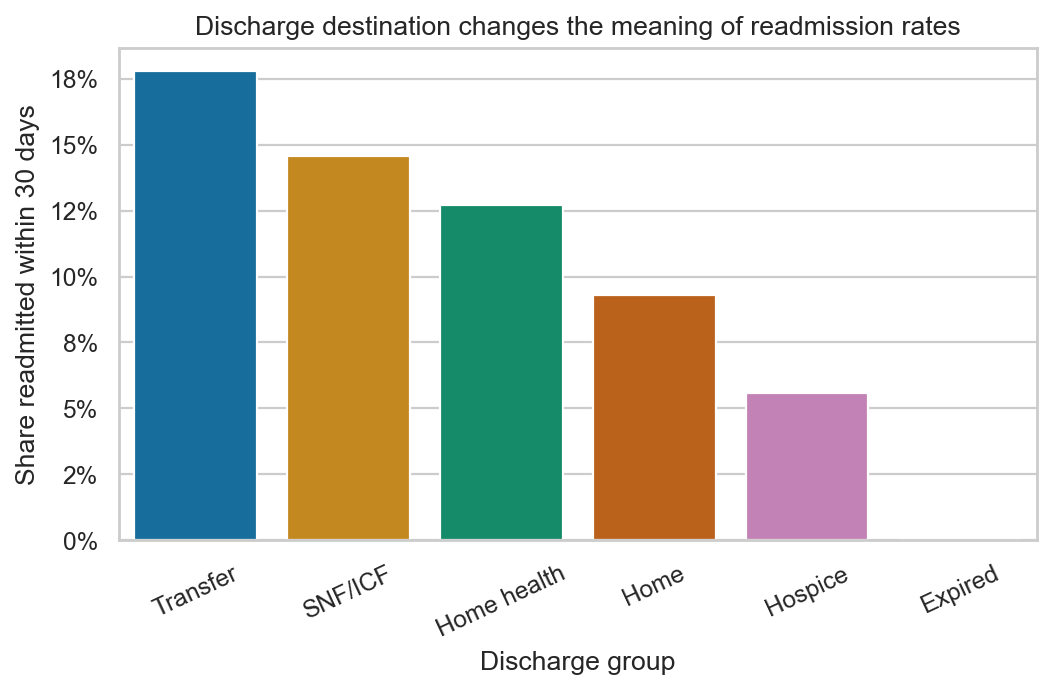

In [13]:
exp = df[df['discharge_group'].isin(['Home', 'Home health', 'SNF/ICF', 'Transfer', 'Expired', 'Hospice'])].groupby('discharge_group', observed=True)['readmit_30'].agg(['mean', 'size']).sort_values('mean', ascending=False).reset_index()
plt.figure(figsize=(7.4, 4.0))
ax = sns.barplot(data=exp, x='discharge_group', y='mean', hue='discharge_group', legend=False)
ax.set(title='Discharge destination changes the meaning of readmission rates', xlabel='Discharge group', ylabel='Share readmitted within 30 days')
ax.tick_params(axis='x', rotation=25)
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
saved_figures['surprise_discharge'] = savefig('surprise_discharge')

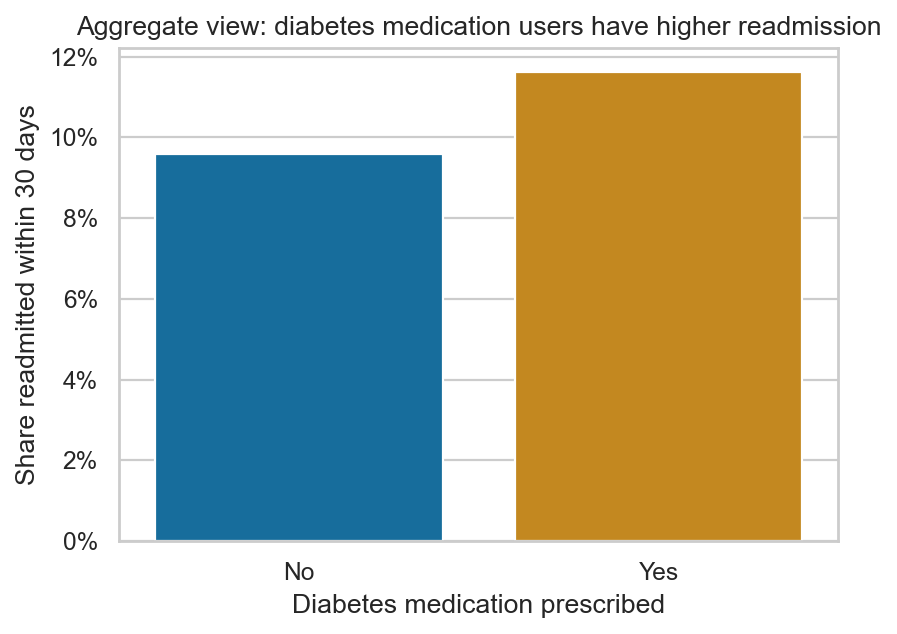

In [14]:
agg = df.groupby('diabetesMed', observed=True)['readmit_30'].mean().reindex(['No', 'Yes']).reset_index()
plt.figure(figsize=(5.8, 4.0))
ax = sns.barplot(data=agg, x='diabetesMed', y='readmit_30', hue='diabetesMed', legend=False)
ax.set(title='Aggregate view: diabetes medication users have higher readmission', xlabel='Diabetes medication prescribed', ylabel='Share readmitted within 30 days')
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
saved_figures['simpson_aggregate'] = savefig('simpson_aggregate')

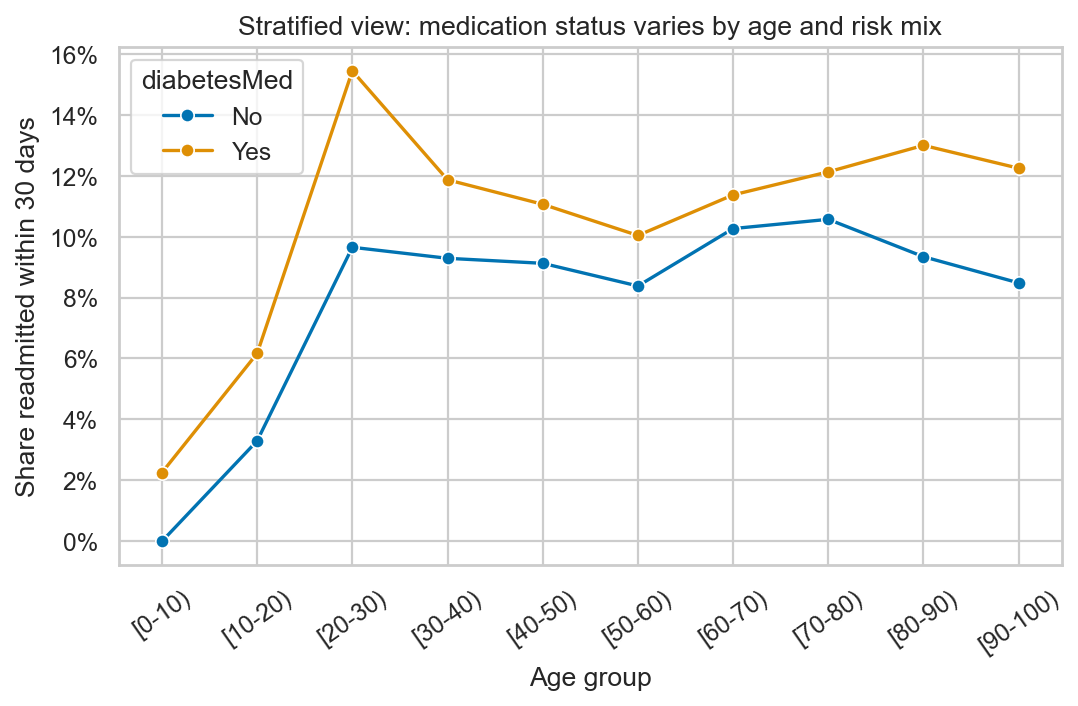

In [15]:
strat = df.groupby(['age', 'diabetesMed'], observed=True)['readmit_30'].mean().reset_index()
plt.figure(figsize=(7.6, 4.2))
ax = sns.lineplot(data=strat, x='age', y='readmit_30', hue='diabetesMed', marker='o')
ax.set(title='Stratified view: medication status varies by age and risk mix', xlabel='Age group', ylabel='Share readmitted within 30 days')
ax.tick_params(axis='x', rotation=35)
ax.yaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')
saved_figures['simpson_stratified'] = savefig('simpson_stratified')

## Anscombe check

In [16]:
corr = df[['time_in_hospital', 'num_medications']].corr().iloc[0, 1]
capped = df[(df['num_medications'] <= df['num_medications'].quantile(.99)) & (df['time_in_hospital'] <= df['time_in_hospital'].quantile(.99))]
corr_capped = capped[['time_in_hospital', 'num_medications']].corr().iloc[0, 1]
corr, corr_capped

(np.float64(0.4661354174307734), np.float64(0.4562525338095841))

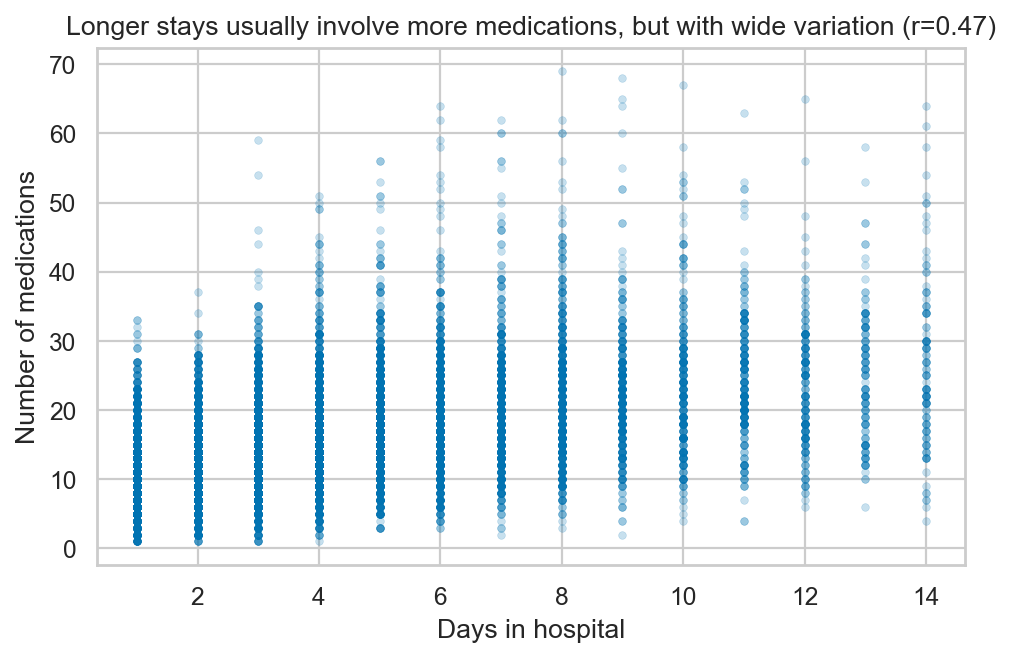

In [17]:
sample = df.sample(12000, random_state=42)
plt.figure(figsize=(7.0, 4.2))
ax = sns.scatterplot(data=sample, x='time_in_hospital', y='num_medications', alpha=0.22, s=12, edgecolor=None)
ax.set(title=f'Longer stays usually involve more medications, but with wide variation (r={corr:.2f})', xlabel='Days in hospital', ylabel='Number of medications')
saved_figures['anscombe_scatter'] = savefig('anscombe_scatter')

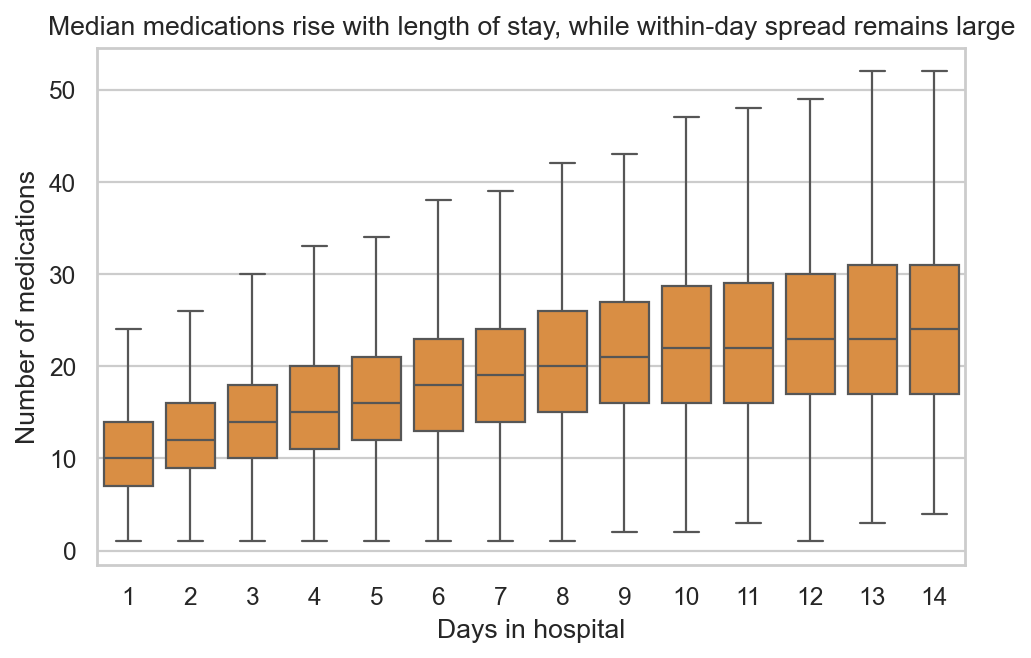

In [18]:
plt.figure(figsize=(7.0, 4.2))
ax = sns.boxplot(data=df, x='time_in_hospital', y='num_medications', color='#f28e2b', showfliers=False)
ax.set(title='Median medications rise with length of stay, while within-day spread remains large', xlabel='Days in hospital', ylabel='Number of medications')
saved_figures['anscombe_box'] = savefig('anscombe_box')

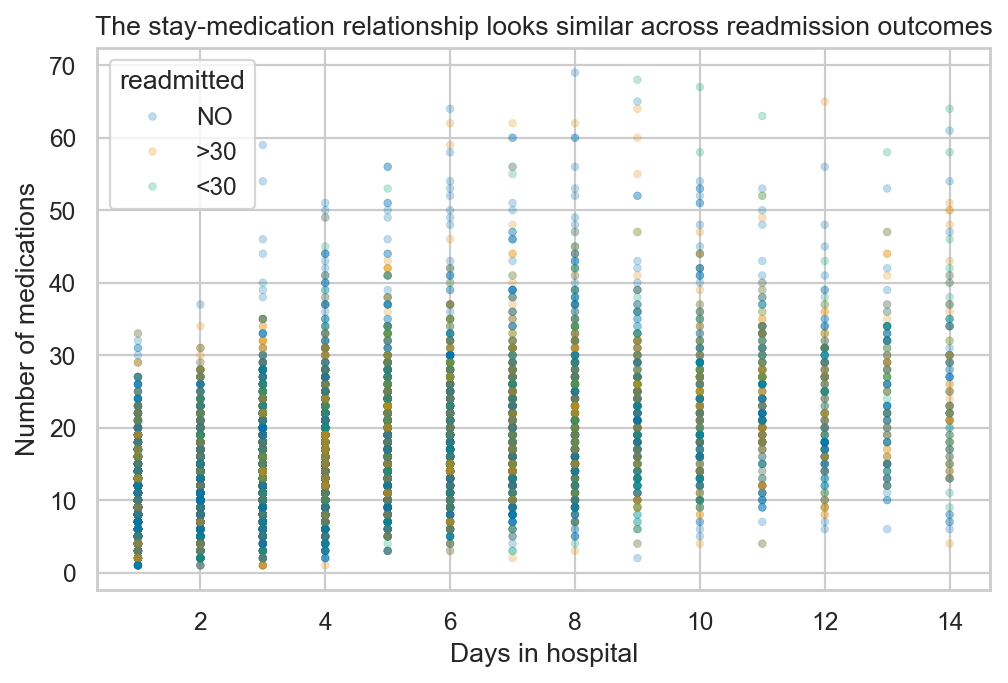

In [19]:
plt.figure(figsize=(7.2, 4.4))
ax = sns.scatterplot(data=sample, x='time_in_hospital', y='num_medications', hue='readmitted', alpha=0.25, s=12, edgecolor=None)
ax.set(title='The stay-medication relationship looks similar across readmission outcomes', xlabel='Days in hospital', ylabel='Number of medications')
saved_figures['anscombe_stratified'] = savefig('anscombe_stratified')

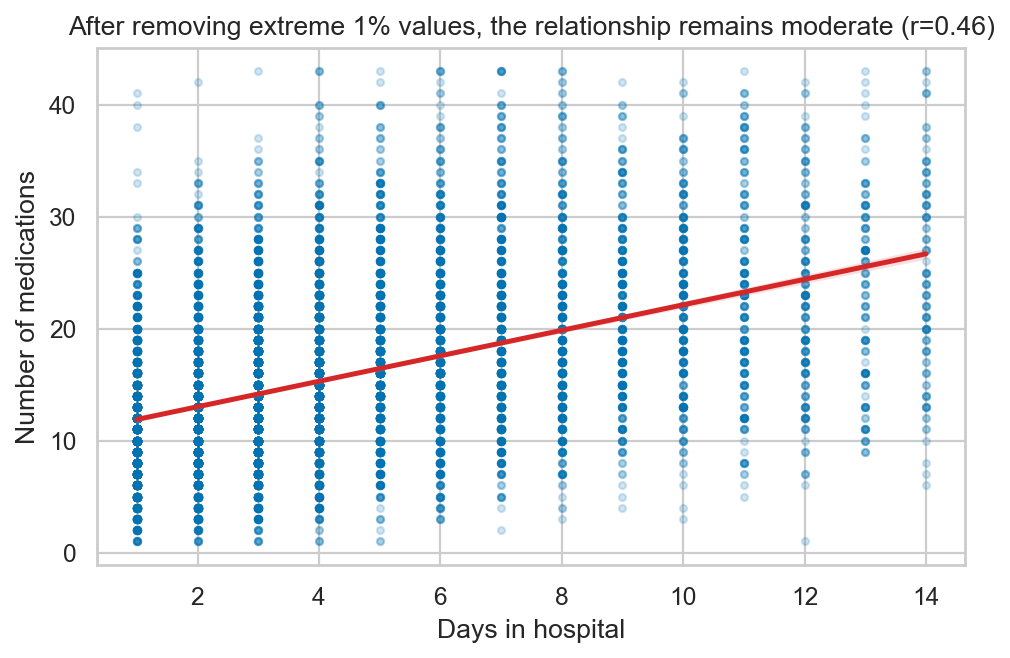

In [20]:
plt.figure(figsize=(7.0, 4.2))
ax = sns.regplot(data=capped.sample(12000, random_state=7), x='time_in_hospital', y='num_medications', scatter_kws={'alpha': .18, 's': 10}, line_kws={'color': '#d62728'})
ax.set(title=f'After removing extreme 1% values, the relationship remains moderate (r={corr_capped:.2f})', xlabel='Days in hospital', ylabel='Number of medications')
saved_figures['anscombe_capped'] = savefig('anscombe_capped')

In [21]:
sorted(saved_figures.values())

['age_distribution.png',
 'anscombe_box.png',
 'anscombe_capped.png',
 'anscombe_scatter.png',
 'anscombe_stratified.png',
 'prior_visits.png',
 'readmitted_distribution.png',
 'rq_a1c_readmit.png',
 'rq_age_readmit.png',
 'rq_prior_utilization.png',
 'simpson_aggregate.png',
 'simpson_stratified.png',
 'surprise_discharge.png',
 'surprise_med_change.png',
 'time_in_hospital.png']